# 01 — From Derivatives to a Backprop Graph

Building up to backpropagation from the definition of a derivative: first
estimating slopes numerically, then wrapping scalars in a `Value` object that
records how it was computed, and finally walking that graph backwards by hand
to get every gradient.

Working through [Andrej Karpathy's *Neural Networks: Zero to Hero*](https://karpathy.ai/zero-to-hero.html),
lecture 1 (micrograd).

> Run top to bottom. Several cells rebind names that earlier cells define —
> see the notes at the end.

## Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## A function to differentiate

A simple quadratic, chosen because its derivative is easy to verify by hand:

$$f(x) = 3x^2 - 4x + 5 \qquad f'(x) = 6x - 4$$

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

## What the function looks like

Plotting over $[-5, 5)$ shows the parabola and, visually, where the slope is
negative, zero, and positive.

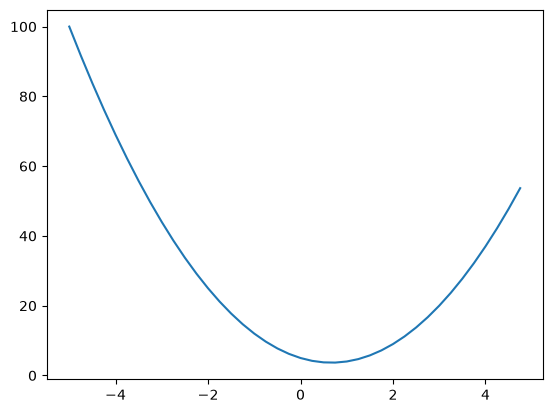

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

## The derivative, numerically

The definition of a derivative is a limit:

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

A computer can't take a limit, so it takes a small $h$ instead. At $x = 3$ the
analytic answer is $6(3) - 4 = 14$ — the numerical estimate should land just
beside it, and the gap is the price of $h$ not actually being zero.

In [5]:
h = 0.001
x = 3.0
(f(x + h) - f(x))/h #slope function

14.00300000000243

`14.003` against an exact `14`. That error is the whole story of numerical
differentiation: shrink $h$ and the estimate improves, until floating-point
cancellation in `f(x + h) - f(x)` starts making it worse again.

Backpropagation exists to avoid this tradeoff entirely — computing exact
derivatives analytically, one operation at a time, instead of estimating them.

**Next:** building the `Value` object that tracks those operations.

---

## Derivatives with more than one input

The same numerical trick, on an expression with three inputs:

$$d = a \cdot b + c$$

Each input has its own derivative. To get one, nudge that input by $h$, hold
the others fixed, and measure how much $d$ moved.

In [6]:
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [7]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a += h
d2 = a*b+c

print('d1:', d1)
print('d2:', d2)
print('slope:', (d2-d1)/h)

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


Nudging `a` gives a slope of about $-3$, which is exactly `b`. That's the
analytic answer: $\partial d / \partial a = b$. Nudging `c` would give $1$,
and nudging `b` would give `a`.

Doing this for every input of every intermediate value is the brute-force way
to get gradients. It costs one full forward pass per input, and each answer
carries the same $h$-sized error as before. The rest of this notebook builds
the machinery that replaces it.

---

## The `Value` object

A scalar that remembers where it came from. Three pieces beyond the number
itself:

- **`_prev`** — the operands this value was computed from
- **`_op`** — which operation produced it
- **`grad`** — the derivative of the final output with respect to this node,
  starting at `0.0` because nothing has been propagated yet

`label` is cosmetic, only there to make the drawings readable.

Because `__add__` and `__mul__` are overloaded, ordinary arithmetic quietly
builds the graph as a side effect — `a*b + c` returns a `Value` whose `_prev`
points back at its parents. Nothing is computing derivatives yet; this is only
the bookkeeping that makes computing them possible.

The expression built below:

$$e = a \cdot b \qquad d = e + c \qquad L = d \cdot f$$

In [8]:
class Value: 
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'
print(L)

Value(data=-8.0)


### What actually got recorded

`d._prev` holds the two `Value`s that produced it and `d._op` holds the symbol.
Those parent pointers, followed recursively, *are* the graph — there's no
separate structure holding it.

In [9]:
#a * b , + c
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [10]:
d._op

'+'

---

## Drawing the graph

`trace` does a depth-first walk from the root, collecting every node and edge
by following `_prev`. `draw_dot` renders each value as a record box showing its
label, data, and grad, plus a small circle for each operation feeding into it.

This needs the graphviz **system binary**, not just the Python package —
`brew install graphviz` on macOS.

In [11]:
from graphviz import Digraph

def trace(root):
    #builds a set of all notes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # Left to Right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular record node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

---

## Backprop by hand

Nothing automates this yet, so the gradients below are worked out manually and
assigned. Starting from $\frac{\partial L}{\partial L} = 1$ and walking
backwards through the chain rule:

| node | derivative | value |
|------|------------|-------|
| `L`  | $\partial L/\partial L$                          | `1.0`  |
| `d`  | $\partial L/\partial d = f$                       | `-2.0` |
| `f`  | $\partial L/\partial f = d$                       | `4.0`  |
| `c`  | $\partial L/\partial c = \partial L/\partial d$  | `-2.0` |
| `e`  | $\partial L/\partial e = \partial L/\partial d$  | `-2.0` |
| `a`  | $\partial L/\partial a = (\partial L/\partial e) \cdot b$ | `6.0`  |
| `b`  | $\partial L/\partial b = (\partial L/\partial e) \cdot a$ | `-4.0` |

Two patterns fall out, and they're the ones the automated version encodes:

- **Addition distributes the gradient unchanged.** `d = e + c`, so `e` and `c`
  both inherit `d.grad` as-is.
- **Multiplication routes each operand the *other's* value**, scaled by the
  output's gradient. `e = a * b`, so `a` gets `e.grad * b` and `b` gets
  `e.grad * a`.

Redrawing the graph now shows real numbers in every `grad` field.

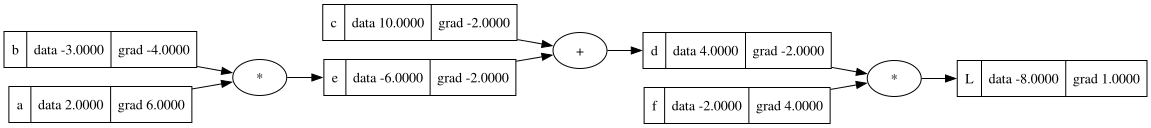

In [12]:
c.grad = -2.0
e.grad = -2.0
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
a.grad = (-2.0 * -3.0)
b.grad = (-2.0 * 2.0)
L.label = 'L'

draw_dot(L)


---

## Notes

Running log for this notebook — what's here, what's missing, and what bit me.

### Covered so far

- The limit definition of a derivative, estimated numerically, and why the
  estimate is never exact
- Numerical derivatives on a multi-input expression, one nudge per input
- A `Value` scalar that records its parents (`_prev`) and operation (`_op`)
  through overloaded `__add__` / `__mul__`
- Graph visualization via `trace` + `draw_dot` (graphviz)
- A complete backward pass computed by hand and assigned to `.grad`

### Gaps in `Value` — the next things to build

- **No scalar operands.** `__add__` and `__mul__` reach straight for
  `other.data`, so `a * 2` raises `AttributeError`. Needs an
  `isinstance(other, (int, float))` wrap at the top of each op.
- **No `_backward`.** Each operation should attach a closure that pushes
  gradient from the output into its children, so the manual assignment above
  becomes automatic.
- **No `backward()` on the root.** Needs a topological sort — a node can only
  be processed once everything downstream of it already has its gradient.
- **Gradients must accumulate, not overwrite.** Once `_backward` exists it has
  to use `+=`. A value used in two places gets a contribution from each path,
  and plain `=` silently keeps only the last one. This is the classic micrograd
  bug and it doesn't show up until a node is reused.
- **Missing ops.** No `tanh`, `exp`, or `**`; no subtraction, division, or
  right-hand variants (`__radd__`, `__rmul__`), so `2 * a` fails even after
  scalar support lands.

### Gotchas hit here

- **`f` gets shadowed.** The quadratic `def f(x)` defined near the top is
  overwritten by `f = Value(-2.0, label='f')` further down. After that cell
  runs, `f(3.0)` raises `TypeError`. Re-run from the top if the early cells are
  needed again.
- **`a`, `b`, `c` change type mid-notebook** — plain floats in the numerical
  section, `Value`s once the class exists. Out-of-order execution mixes them.
- **graphviz is two installs**, the Python package and the system binary.
  Missing the binary gives an `ExecutableNotFound` at `draw_dot`, not at import.

### Reference

- [Neural Networks: Zero to Hero](https://karpathy.ai/zero-to-hero.html) — lecture 1
- [karpathy/micrograd](https://github.com/karpathy/micrograd) — the finished engine